In [ ]:
#%% !pip install pandas openpyxl ydata-profiling
#%pip install "setuptools<82"

## Notebook para chequear calidad de datos de la base de detección de señales en estados contables


In [12]:
import pandas as pd
from pathlib import Path
import pandas as pd
from ydata_profiling import ProfileReport

from matplotlib.lines import Line2D

## Chequeos rapidos

In [4]:
excel_path = Path.cwd().parent / "Ejercicio_1_datos_y_etiquetas.xlsx"
df = pd.read_excel(excel_path, sheet_name="Datos")

# 1. Duplicados de fila completa
print(f"Filas totalmente duplicadas: {df.duplicated().sum()}")

# 2. Duplicados de identificador
print(f"firm_id duplicados: {df['firm_id'].duplicated().sum()}")

# 3. Duplicados de contenido financiero (sin ID ni nombre)
print(f"Duplicados de contenido financiero: "
      f"{df.drop(columns=['firm_id','firm_name']).duplicated().sum()}")

Filas totalmente duplicadas: 0
firm_id duplicados: 0
Duplicados de contenido financiero: 0


In [5]:
df.columns

Index(['firm_id', 'firm_name', 'sector', 'reporting_period',
       'revenue_reported_mm', 'revenue_growth_pct',
       'operating_expenses_reported_mm', 'ebitda_reported_mm',
       'ebitda_margin_change_pp', 'cfo_reported_mm', 'capex_total_reported_mm',
       'capex_growth_pct', 'maintenance_capex_reported_mm',
       'growth_capex_reported_mm', 'adjusted_ebitda_reported_mm',
       'interest_expense_reported_mm', 'cash_taxes_reported_mm',
       'net_income_reported_mm', 'dividends_mm', 'debt_avg_mm',
       'debt_end_reported_mm', 'total_assets_reported_mm', 'cash_reported_mm',
       'accounts_receivable_reported_mm', 'inventory_reported_mm',
       'npl_reported_mm', 'npl_growth_pct', 'provision_reported_mm',
       'loan_loss_reserve_reported_mm', 'coverage_change_pp',
       'ebitda_margin_pct', 'cfo_margin_pct', 'capex_intensity_pct',
       'maintenance_capex_share_pct', 'fcf_reported_mm',
       'distributable_cash_flow_reported_mm', 'dcf_fcf_gap_mm',
       'dividend_cover

In [7]:
num_cols = df.select_dtypes(include='number').columns.drop('sector', errors='ignore')

results = {}
for col in num_cols:
    res = df.groupby('sector')[col].agg(['mean', 'min', 'max']).reset_index()
    results[col] = res
    print(f"--- {col} ---")
    print(res)

--- revenue_reported_mm ---
        sector        mean        min          max
0     Consumer  220.811668  62.025435   682.331507
1       Energy  300.279439  70.558198  1438.757397
2   Financials  221.053837  48.349274   785.790473
3  Industrials  286.600429  59.360601   946.762197
4   Technology  195.458368  49.444256   743.822805
--- revenue_growth_pct ---
        sector      mean       min       max
0     Consumer  0.011516 -0.140520  0.123386
1       Energy  0.010865 -0.113468  0.131750
2   Financials  0.007251 -0.138872  0.107762
3  Industrials  0.014257 -0.130162  0.110987
4   Technology  0.060422 -0.099736  0.163869
--- operating_expenses_reported_mm ---
        sector        mean        min         max
0     Consumer  188.555720  54.537332  548.719117
1       Energy  221.787824  51.698933  913.977161
2   Financials  148.040007  32.411376  488.529129
3  Industrials  239.742045  47.233360  731.067069
4   Technology  148.372207  39.239553  613.990450
--- ebitda_reported_mm ---
   

## Pandas Profiling

In [9]:

# profile = ProfileReport(
#     df,
#     title="Reporte de perfilado",
#     explorative=True,
#     minimal=False
# )

# profile.to_file("reporte_ydata_profiling.html")

profile = ProfileReport(
    df,
    title="Reporte de perfilado",
    explorative=True,
    minimal=True
)

profile.to_file("reporte_ydata_profiling_minimal.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 331.12it/s]


## Analisis de las distribuciones de algunas variables financieras relevantes

In [8]:
variables = {
    'ebitda_margin_pct': 'EBITDA margin',
    'cfo_margin_pct': 'CFO margin',
    'capex_intensity_pct': 'Capex intensity',
    'cfo_to_ebitda_reported_x': 'CFO / EBITDA',
    'maintenance_capex_share_pct': 'Maintenance capex share',
    'dcf_fcf_gap_mm': 'DCF - FCF gap (mm)',
    'leverage_avg_x': 'Leverage (avg)',
    'debt_end_to_avg_x': 'Debt end / avg'
}

datos = df[list(variables)]

q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1

tabla = pd.DataFrame({
    'Skew': datos.skew(),
    'Curtosis (exceso)': datos.kurt(),
    '% outliers (IQR)': ((datos < q1 - 1.5 * iqr) | (datos > q3 + 1.5 * iqr)).sum() / datos.count() * 100
}).rename(index=variables)

print(tabla.round({'Skew': 2, 'Curtosis (exceso)': 2, '% outliers (IQR)': 1}))

                         Skew  Curtosis (exceso)  % outliers (IQR)
EBITDA margin            0.33              -0.48               0.0
CFO margin               0.32              -0.29               0.3
Capex intensity          1.20               0.43               5.3
CFO / EBITDA            -2.59              13.24               3.8
Maintenance capex share -0.25               0.32               0.6
DCF - FCF gap (mm)       1.30               5.84               6.6
Leverage (avg)           0.05              -1.06               0.0
Debt end / avg          -1.02               2.71               1.7


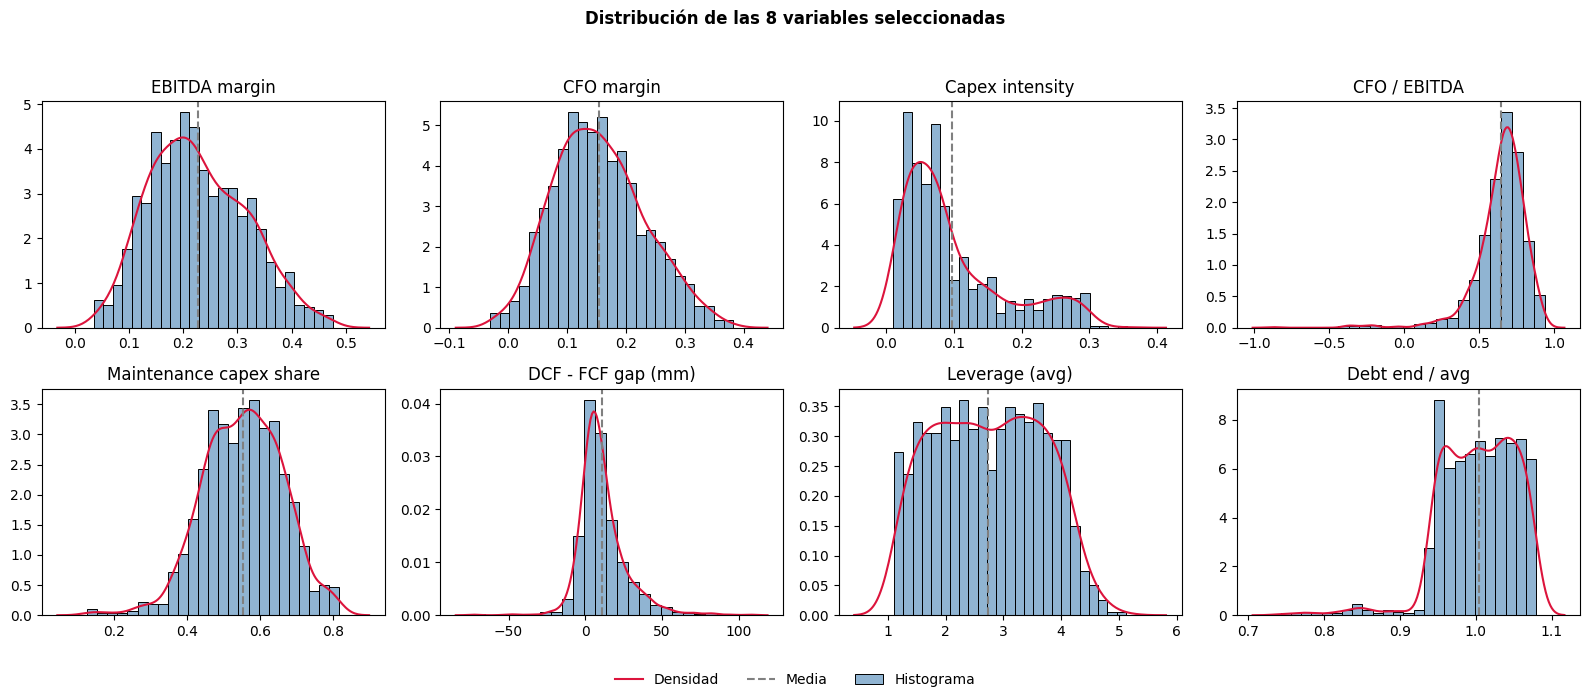

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for (columna, titulo), ax in zip(variables.items(), axes.flat):
    x = df[columna].dropna()

    sns.histplot(x, bins=25, stat='density', color='steelblue', alpha=0.6,
                 label='Histograma', ax=ax)
    sns.kdeplot(x, color='crimson', linewidth=1.5, label='Densidad', ax=ax)
    ax.axvline(x.mean(), color='gray', linestyle='--', label='Media')

    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Distribución de las 8 variables seleccionadas', fontweight='bold')
fig.legend(*axes[0, 0].get_legend_handles_labels(),
           loc='lower center', ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

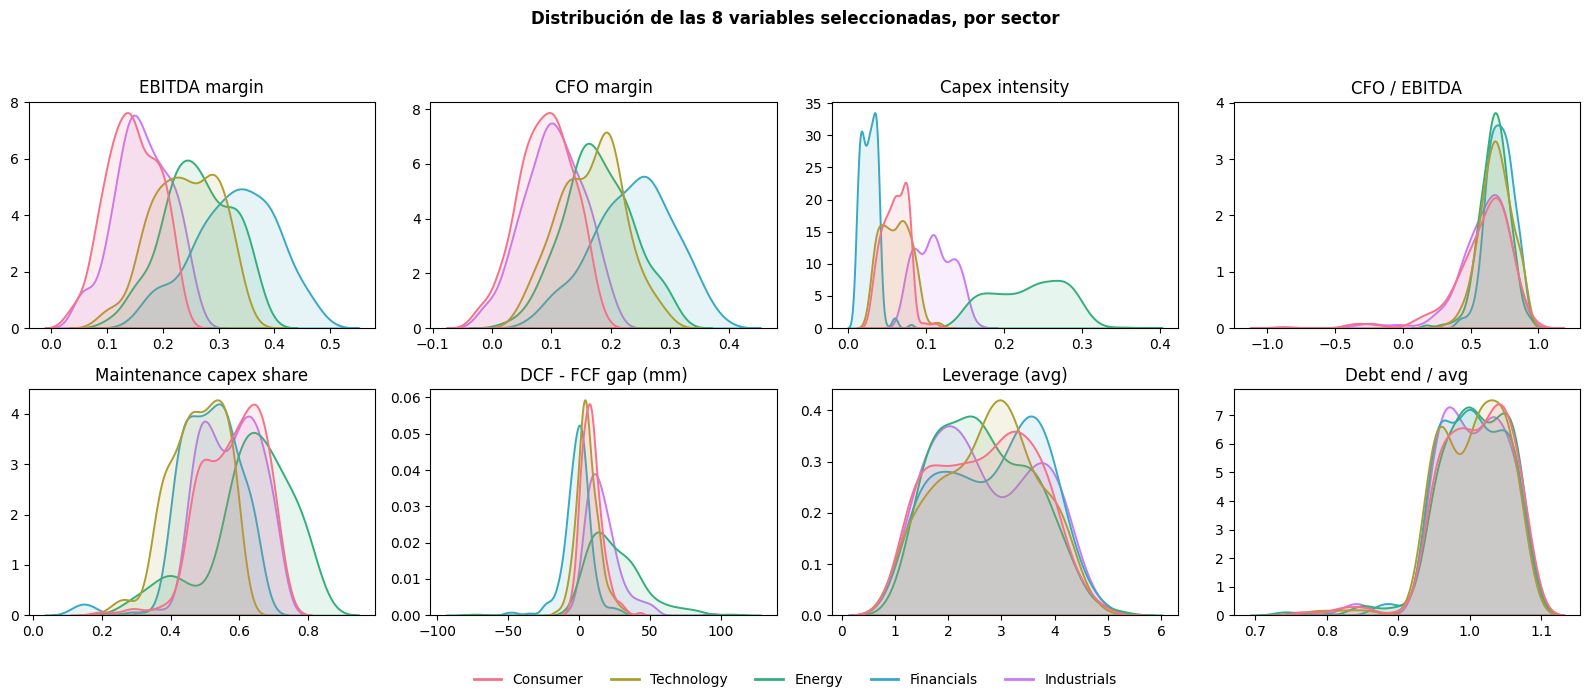

In [13]:
sectores = df['sector'].dropna().unique()
colores = sns.color_palette('husl', len(sectores))
paleta = dict(zip(sectores, colores))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for (columna, titulo), ax in zip(variables.items(), axes.flat):
    sns.kdeplot(
        data=df,
        x=columna,
        hue='sector',
        hue_order=sectores,
        palette=paleta,
        fill=True,
        common_norm=False,
        alpha=0.12,
        linewidth=1.4,
        legend=False,
        ax=ax
    )

    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('')

leyenda = [
    Line2D([0], [0], color=paleta[sector], linewidth=2, label=sector)
    for sector in sectores
]

fig.suptitle('Distribución de las 8 variables seleccionadas, por sector',
             fontweight='bold')
fig.legend(handles=leyenda, loc='lower center', ncol=len(sectores), frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()